In [ ]:
# Aplicação de Inteligência Artificial no mapeamento de vigor vegetativo em lavouras utilizando imagens de drones

# Autor: Kenzo Ramos Otaguiri
# Disciplina: Inteligência Artificial
# UNIUBE - 2026

In [1]:
!pip install gradio -q

import os
import zipfile
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gradio as gr
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.utils import load_img, img_to_array
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
zip_path = "/content/archive.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extraído com sucesso!")

Dataset extraído com sucesso!


In [3]:
caminho_dataset = "/content/dataset/UAVs Images"

classes = os.listdir(caminho_dataset)

print("Classes encontradas:")
for classe in classes:
    print("-", classe)

Classes encontradas:
- Rice husk charcoal
- Indian mustard (Brassica juncea)
- Fallow (left bare)
- Dolomite gypsum


In [4]:
img_size = (128, 128)
batch_size = 32
seed = 123

treino = tf.keras.utils.image_dataset_from_directory(
    caminho_dataset,
    validation_split=0.2,
    subset="training",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size
)

validacao = tf.keras.utils.image_dataset_from_directory(
    caminho_dataset,
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size
)

classes = treino.class_names

print("Classes:", classes)

Found 1927 files belonging to 4 classes.
Using 1542 files for training.
Found 1927 files belonging to 4 classes.
Using 385 files for validation.
Classes: ['Dolomite gypsum', 'Fallow (left bare)', 'Indian mustard (Brassica juncea)', 'Rice husk charcoal']


In [5]:
AUTOTUNE = tf.data.AUTOTUNE

treino = treino.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
validacao = validacao.cache().prefetch(buffer_size=AUTOTUNE)

In [6]:
modelo = models.Sequential([
    layers.Input(shape=(128, 128, 3)),
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(len(classes), activation='softmax')
])

modelo.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
historico = modelo.fit(
    treino,
    validation_data=validacao,
    epochs=10
)

Epoch 1/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 52s 990ms/step - accuracy: 0.8100 - loss: 0.4698 - val_accuracy: 0.9506 - val_loss: 0.0925
Epoch 2/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 79s 952ms/step - accuracy: 0.9546 - loss: 0.1159 - val_accuracy: 0.9870 - val_loss: 0.0375
Epoch 3/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 81s 923ms/step - accuracy: 0.9812 - loss: 0.0539 - val_accuracy: 0.9818 - val_loss: 0.0339
Epoch 4/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 46s 944ms/step - accuracy: 0.9916 - loss: 0.0296 - val_accuracy: 1.0000 - val_loss: 0.0078
Epoch 5/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 80s 907ms/step - accuracy: 0.9844 - loss: 0.0532 - val_accuracy: 0.9974 - val_loss: 0.0167
Epoch 6/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 84s 943ms/step - accuracy: 0.9935 - loss: 0.0270 - val_accuracy: 0.9948 - val_loss: 0.0107
Epoch 7/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 45s 911ms/step - accuracy: 0.9994 - loss: 0.0055 - val_accuracy: 1.0000 - val_loss: 0.0018
Epoch 8/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 47s 965ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accu

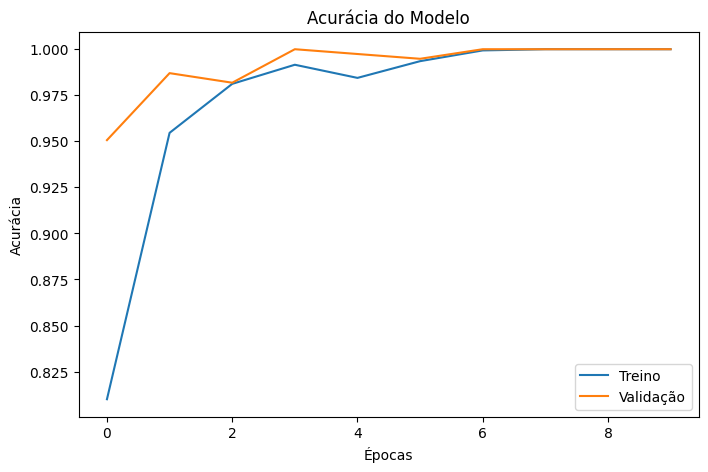

In [8]:
plt.figure(figsize=(8,5))
plt.plot(historico.history['accuracy'], label='Treino')
plt.plot(historico.history['val_accuracy'], label='Validação')
plt.title('Acurácia do Modelo')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
plt.savefig('grafico_acuracia.png', dpi=300, bbox_inches='tight')
plt.show()

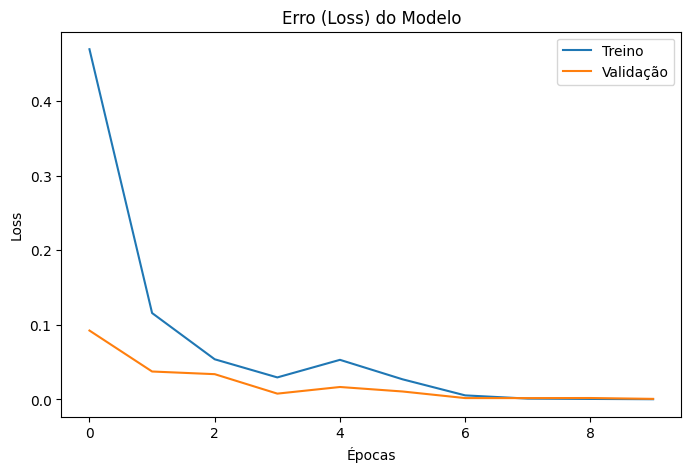

In [9]:
plt.figure(figsize=(8,5))
plt.plot(historico.history['loss'], label='Treino')
plt.plot(historico.history['val_loss'], label='Validação')
plt.title('Erro (Loss) do Modelo')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.savefig('grafico_loss.png', dpi=300, bbox_inches='tight')
plt.show()

In [10]:
y_true = np.concatenate([y for x, y in validacao], axis=0)

y_pred = modelo.predict(validacao)
y_pred = np.argmax(y_pred, axis=1)

relatorio = classification_report(
    y_true,
    y_pred,
    target_names=classes
)

print(relatorio)

with open("metricas.txt", "w") as f:
    f.write(relatorio)

13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 584ms/step
                                  precision    recall  f1-score   support

                 Dolomite gypsum       1.00      1.00      1.00       130
              Fallow (left bare)       1.00      1.00      1.00        68
Indian mustard (Brassica juncea)       1.00      1.00      1.00       106
              Rice husk charcoal       1.00      1.00      1.00        81

                        accuracy                           1.00       385
                       macro avg       1.00      1.00      1.00       385
                    weighted avg       1.00      1.00      1.00       385



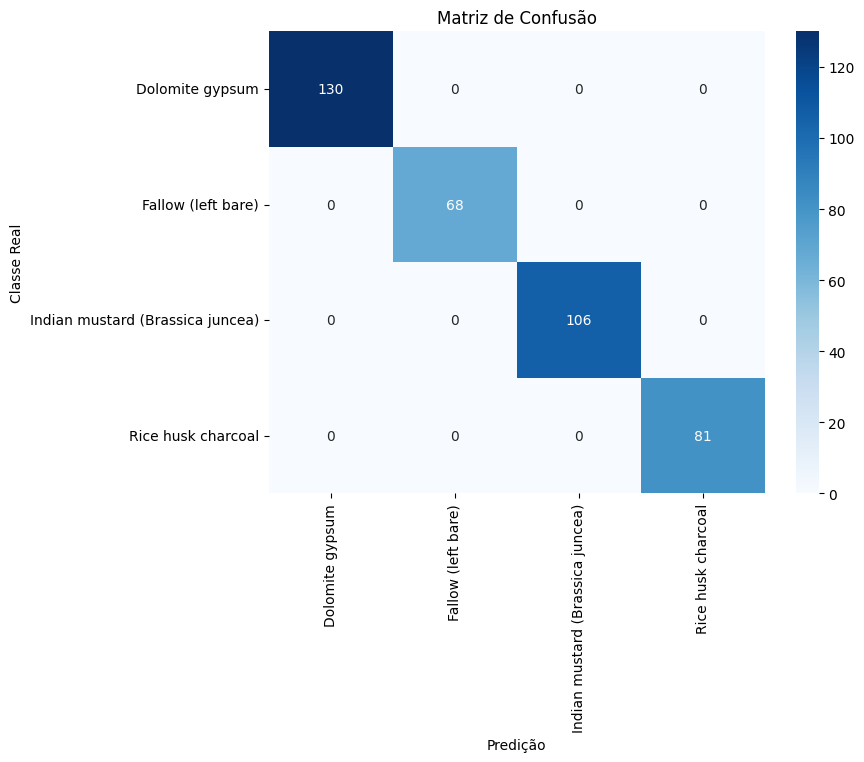

In [11]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel('Predição')
plt.ylabel('Classe Real')
plt.title('Matriz de Confusão')
plt.savefig('matriz_confusao.png', dpi=300, bbox_inches='tight')
plt.show()

In [12]:
modelo.save("modelo_agricola.keras")
print("Modelo salvo com sucesso!")

Modelo salvo com sucesso!


In [13]:
def classificar_imagem(imagem_path):
    img = load_img(imagem_path, target_size=(128, 128))
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    pred = modelo.predict(img_array)

    classe_prevista = classes[np.argmax(pred)]
    confianca = np.max(pred) * 100

    return classe_prevista, confianca

In [14]:
def analisar_vigor(imagem_path):
    img = cv2.imread(imagem_path)

    if img is None:
        return None, None, None

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)

    verde_baixo = np.array([35, 40, 40])
    verde_alto = np.array([85, 255, 255])

    mascara = cv2.inRange(hsv, verde_baixo, verde_alto)

    pixels_verdes = cv2.countNonZero(mascara)
    total_pixels = mascara.shape[0] * mascara.shape[1]
    percentual = (pixels_verdes / total_pixels) * 100

    if percentual < 25:
        vigor = "Baixo"
    elif percentual < 55:
        vigor = "Médio"
    else:
        vigor = "Alto"

    return percentual, vigor, mascara

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step
Classe prevista: Indian mustard (Brassica juncea)
Confiança: 100.00%
Cobertura vegetal: 37.15%
Vigor vegetativo: Médio


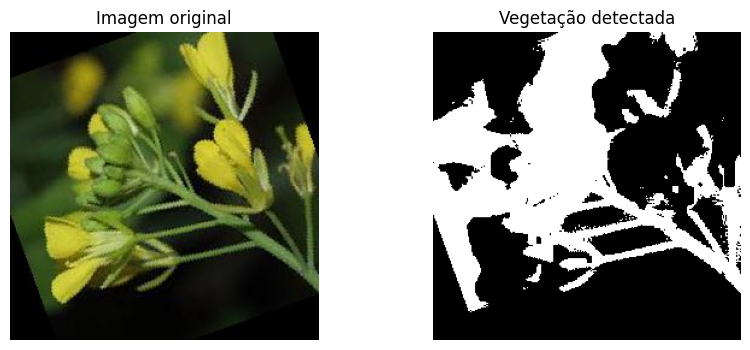

In [15]:
pasta_teste = "/content/dataset/UAVs Images/Indian mustard (Brassica juncea)"
imagem_teste = os.path.join(pasta_teste, os.listdir(pasta_teste)[0])

classe, confianca = classificar_imagem(imagem_teste)
percentual, vigor, mascara = analisar_vigor(imagem_teste)

print("Classe prevista:", classe)
print(f"Confiança: {confianca:.2f}%")
print(f"Cobertura vegetal: {percentual:.2f}%")
print("Vigor vegetativo:", vigor)

img = cv2.imread(imagem_teste)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("Imagem original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mascara, cmap="gray")
plt.title("Vegetação detectada")
plt.axis("off")

plt.savefig("vigor_vegetativo.png", dpi=300, bbox_inches='tight')
plt.show()

In [17]:
def sistema_completo(imagem_path):
    classe, confianca = classificar_imagem(imagem_path)
    percentual, vigor, mascara = analisar_vigor(imagem_path)

    resultado = (
        f"Classe prevista: {classe}\n"
        f"Confiança: {confianca:.2f}%\n"
        f"Cobertura vegetal: {percentual:.2f}%\n"
        f"Vigor vegetativo: {vigor}"
    )

    return resultado

interface = gr.Interface(
    fn=sistema_completo,
    inputs=gr.Image(type="filepath"),
    outputs="text",
    title="Classificador Agrícola com IA / Kenzo",
    description="Sistema baseado em CNN para classificação de imagens agrícolas e estimativa de vigor vegetativo."
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f097f111883cf7476b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
